Market-basket analysis with FP-Growth

In [5]:
#%pip install mlxtend

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [7]:
current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

master_file = (
    project_root
    / "data"
    / "processed"
    / "retailiq_cleaned_master.csv.gz"
)

basket_columns = [
    "Invoice",
    "StockCodeNormalized",
    "Description",
    "Quantity",
    "InvoiceDate",
    "CustomerID",
    "TransactionType",
    "IsExactReversalPair"
]

market_basket_df = pd.read_csv(
    master_file,
    usecols=basket_columns,
    parse_dates=["InvoiceDate"],
    dtype={
        "Invoice": "string",
        "StockCodeNormalized": "string",
        "Description": "string",
        "CustomerID": "Int64",
        "TransactionType": "category",
        "IsExactReversalPair": "boolean"
    }
)

print("Imported shape:", market_basket_df.shape)
market_basket_df.head()

Imported shape: (1033036, 8)


,Invoice,Description,Quantity,InvoiceDate,CustomerID,StockCodeNormalized,TransactionType,IsExactReversalPair
0,489434,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,13085,85048,Sale,False
1,489434,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,13085,79323P,Sale,False
2,489434,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,13085,79323W,Sale,False
3,489434,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,13085,22041,Sale,False
4,489434,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,13085,21232,Sale,False


Create valid basket lines

Use only genuine positive sales and exclude exact reversal pairs:

In [8]:
basket_lines = market_basket_df.loc[
    market_basket_df["TransactionType"].eq("Sale")
    & market_basket_df["Invoice"].notna()
    & market_basket_df["StockCodeNormalized"].notna()
    & market_basket_df["Quantity"].gt(0)
    & ~market_basket_df[
        "IsExactReversalPair"
    ].fillna(False)
].copy()

In [9]:
basket_lines = basket_lines.drop_duplicates(
    subset=[
        "Invoice",
        "StockCodeNormalized"
    ]
)

basket_validation = pd.Series({
    "Basket lines": len(basket_lines),
    "Unique invoices": basket_lines["Invoice"].nunique(),
    "Unique products": basket_lines[
        "StockCodeNormalized"
    ].nunique(),
    "Duplicate invoice-product pairs": (
        basket_lines.duplicated(
            ["Invoice", "StockCodeNormalized"]
        ).sum()
    ),
    "Non-sale rows": (
        ~basket_lines["TransactionType"].eq("Sale")
    ).sum(),
    "Non-positive quantities": (
        basket_lines["Quantity"] <= 0
    ).sum()
})

basket_validation

Basket lines                       986237
Unique invoices                     39267
Unique products                      4725
Duplicate invoice-product pairs         0
Non-sale rows                           0
Non-positive quantities                 0
dtype: int64

Select the top 1,000 products

Using all products could make FP-Growth slow and produce many weak rules. Rank products by the number of invoices in which they appear:

In [10]:
MAX_PRODUCTS = 1000

product_invoice_support = (
    basket_lines
    .groupby("StockCodeNormalized")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
)

selected_products = (
    product_invoice_support
    .head(MAX_PRODUCTS)
    .index
)

basket_model_lines = basket_lines.loc[
    basket_lines["StockCodeNormalized"].isin(
        selected_products
    )
].copy()

product_selection_summary = pd.Series({
    "Products before selection": (
        basket_lines["StockCodeNormalized"].nunique()
    ),
    "Products selected": (
        basket_model_lines[
            "StockCodeNormalized"
        ].nunique()
    ),
    "Invoices retained": (
        basket_model_lines["Invoice"].nunique()
    ),
    "Invoice-product pairs": len(basket_model_lines)
})

product_selection_summary

Products before selection      4725
Products selected              1000
Invoices retained             37703
Invoice-product pairs        679095
dtype: int64

In [11]:
products_per_invoice = (
    basket_model_lines
    .groupby("Invoice")[
        "StockCodeNormalized"
    ]
    .nunique()
)

basket_size_summary = pd.Series({
    "All invoices": len(products_per_invoice),
    "Single-product invoices": (
        products_per_invoice == 1
    ).sum(),
    "Multi-product invoices": (
        products_per_invoice >= 2
    ).sum(),
    "Average products per invoice": (
        products_per_invoice.mean()
    )
})

basket_size_summary

All invoices                    37703.000000
Single-product invoices          3206.000000
Multi-product invoices          34497.000000
Average products per invoice       18.011697
dtype: float64

Exclude single-product invoices

In [12]:
eligible_invoices = products_per_invoice.loc[
    products_per_invoice >= 2
].index

basket_model_lines = basket_model_lines.loc[
    basket_model_lines["Invoice"].isin(
        eligible_invoices
    )
].copy()

print(
    "Eligible multi-product invoices:",
    basket_model_lines["Invoice"].nunique()
)

print(
    "Invoice-product pairs:",
    len(basket_model_lines)
)

Eligible multi-product invoices: 34497
Invoice-product pairs: 675889


### Basket Eligibility Rule

Association-rule analysis requires at least two distinct products in a basket. Therefore, invoices containing fewer than two of the selected products are excluded. The resulting support values describe product relationships within multi-product transactions.

Build the sparse basket matrix

In [13]:
invoice_codes, invoice_labels = pd.factorize(
    basket_model_lines["Invoice"],
    sort=True
)

product_codes, product_labels = pd.factorize(
    basket_model_lines["StockCodeNormalized"],
    sort=True
)

sparse_values = np.ones(
    len(basket_model_lines),
    dtype=np.uint8
)

sparse_matrix = csr_matrix(
    (
        sparse_values,
        (
            invoice_codes,
            product_codes
        )
    ),
    shape=(
        len(invoice_labels),
        len(product_labels)
    )
)

basket_matrix = (
    pd.DataFrame.sparse.from_spmatrix(
        sparse_matrix,
        index=invoice_labels,
        columns=product_labels
    )
    .astype(
        pd.SparseDtype(bool, False)
    )
)

basket_matrix.index.name = "Invoice"
basket_matrix.columns.name = "StockCodeNormalized"

print("Basket matrix shape:", basket_matrix.shape)
print("Non-zero entries:", sparse_matrix.nnz)

Basket matrix shape: (34497, 1000)
Non-zero entries: 675889


Validate the matrix

In [14]:
basket_density = (
    sparse_matrix.nnz
    / (
        sparse_matrix.shape[0]
        * sparse_matrix.shape[1]
    )
    * 100
)

matrix_validation = pd.Series({
    "Invoices": basket_matrix.shape[0],
    "Products": basket_matrix.shape[1],
    "Product presences": sparse_matrix.nnz,
    "Expected presences": len(basket_model_lines),
    "Matrix density percent": basket_density,
    "Duplicate invoice-product pairs": (
        basket_model_lines.duplicated(
            [
                "Invoice",
                "StockCodeNormalized"
            ]
        ).sum()
    )
})

matrix_validation

Invoices                            34497.000000
Products                             1000.000000
Product presences                  675889.000000
Expected presences                 675889.000000
Matrix density percent                  1.959269
Duplicate invoice-product pairs         0.000000
dtype: float64

In [15]:
assert basket_matrix.shape[1] <= MAX_PRODUCTS
assert sparse_matrix.nnz == len(basket_model_lines)
assert basket_model_lines.duplicated(
    ["Invoice", "StockCodeNormalized"]
).sum() == 0

print("Sparse basket matrix validation passed.")

Sparse basket matrix validation passed.


Generate frequent itemsets

Use a minimum support of 0.005. This requires an itemset to appear in at least approximately 173 baskets.

In [16]:
MIN_SUPPORT = 0.005
MAX_ITEMSET_LENGTH = 3

minimum_basket_count = int(
    np.ceil(
        MIN_SUPPORT
        * basket_matrix.shape[0]
    )
)

print(
    "Minimum required basket count:",
    minimum_basket_count
)

Minimum required basket count: 173


Run FP-Growth:

In [17]:
frequent_itemsets = fpgrowth(
    basket_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_LENGTH
)

frequent_itemsets["ItemsetSize"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

frequent_itemsets["BasketCount"] = (
    frequent_itemsets["support"]
    * basket_matrix.shape[0]
).round().astype(int)

frequent_itemsets = (
    frequent_itemsets
    .sort_values(
        ["ItemsetSize", "support"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print(
    "Frequent itemsets found:",
    len(frequent_itemsets)
)

frequent_itemsets[
    "ItemsetSize"
].value_counts().sort_index()

Frequent itemsets found: 10157


ItemsetSize
1    1000
2    6350
3    2807
Name: count, dtype: int64

Validate:

In [18]:
assert frequent_itemsets["support"].ge(
    MIN_SUPPORT
).all()

assert frequent_itemsets[
    "ItemsetSize"
].le(MAX_ITEMSET_LENGTH).all()

print("Frequent-itemset validation passed.")

Frequent-itemset validation passed.


Inspect the strongest multi-product itemsets:

In [19]:
frequent_itemsets.loc[
    frequent_itemsets["ItemsetSize"] >= 2
].sort_values(
    "support",
    ascending=False
).head(30)

,support,itemsets,ItemsetSize,BasketCount
1000,0.041134,"frozenset({85099B, 22386})",2,1419
1001,0.038235,"frozenset({21931, 85099B})",2,1319
1002,0.035800,"frozenset({21733, 85123A})",2,1235
1003,0.034670,"frozenset({20725, 20727})",2,1196
1004,0.034525,"frozenset({21212, 84991})",2,1191
1005,0.034293,"frozenset({85099B, 85099F})",2,1183
1006,0.033945,"frozenset({20725, 22383})",2,1171
1007,0.033539,"frozenset({85099B, 22411})",2,1157
1008,0.033307,"frozenset({20725, 22384})",2,1149
1009,0.032119,"frozenset({21977, 21212})",2,1108


Generate association rules

Generate a broad rule set using a minimum confidence of 40%:

In [20]:
MIN_CONFIDENCE = 0.40

association_rule_results = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

association_rule_results[
    "AntecedentSize"
] = association_rule_results[
    "antecedents"
].apply(len)

association_rule_results[
    "ConsequentSize"
] = association_rule_results[
    "consequents"
].apply(len)

association_rule_results[
    "BasketCount"
] = (
    association_rule_results["support"]
    * basket_matrix.shape[0]
).round().astype(int)

print(
    "Association rules generated:",
    len(association_rule_results)
)

Association rules generated: 6305


Create actionable rules

For clear product recommendations:

Consequent must contain one product.
Antecedent can contain one or two products.
Confidence must be at least 50%.
Lift must be at least 1.20.
Support remains at least 0.5%.

In [21]:
ACTIONABLE_CONFIDENCE = 0.50
ACTIONABLE_LIFT = 1.20

actionable_rules = association_rule_results.loc[
    association_rule_results["support"].ge(
        MIN_SUPPORT
    )
    & association_rule_results["confidence"].ge(
        ACTIONABLE_CONFIDENCE
    )
    & association_rule_results["lift"].ge(
        ACTIONABLE_LIFT
    )
    & association_rule_results[
        "AntecedentSize"
    ].between(1, 2)
    & association_rule_results[
        "ConsequentSize"
    ].eq(1)
    & np.isfinite(
        association_rule_results["lift"]
    )
].copy()

actionable_rules = (
    actionable_rules
    .sort_values(
        [
            "lift",
            "confidence",
            "support"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Actionable rules:",
    len(actionable_rules)
)

Actionable rules: 4048


Validation

In [22]:
rule_validation = pd.Series({
    "Rules generated": len(
        association_rule_results
    ),
    "Actionable rules": len(
        actionable_rules
    ),
    "Minimum support": (
        actionable_rules["support"].min()
    ),
    "Minimum confidence": (
        actionable_rules["confidence"].min()
    ),
    "Minimum lift": (
        actionable_rules["lift"].min()
    ),
    "Maximum antecedent size": (
        actionable_rules["AntecedentSize"].max()
    ),
    "Maximum consequent size": (
        actionable_rules["ConsequentSize"].max()
    )
})

rule_validation

Rules generated            6305.000000
Actionable rules           4048.000000
Minimum support               0.005015
Minimum confidence            0.500000
Minimum lift                  3.219806
Maximum antecedent size       2.000000
Maximum consequent size       1.000000
dtype: float64

In [23]:
assert actionable_rules["support"].ge(
    MIN_SUPPORT
).all()

assert actionable_rules["confidence"].ge(
    ACTIONABLE_CONFIDENCE
).all()

assert actionable_rules["lift"].ge(
    ACTIONABLE_LIFT
).all()

assert actionable_rules[
    "ConsequentSize"
].eq(1).all()

print("Association-rule validation passed.")

Association-rule validation passed.


Inspect the strongest rules:

In [24]:
actionable_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift",
        "BasketCount"
    ]
].head(30)

,antecedents,consequents,support,confidence,lift,BasketCount
0,"frozenset({22523, 22520})",frozenset({22522}),0.006435,0.925000,96.113630,222
1,"frozenset({23266, 23263})",frozenset({23265}),0.005015,0.797235,94.185673,173
2,"frozenset({23173, 23175})",frozenset({23174}),0.005566,0.853333,91.992000,192
3,"frozenset({22521, 22522})",frozenset({22523}),0.006232,0.930736,91.735993,215
4,"frozenset({22521, 22522})",frozenset({22520}),0.006435,0.961039,90.581861,222
5,"frozenset({23170, 23171})",frozenset({23172}),0.007334,0.798107,90.566796,253
6,"frozenset({23263, 23265})",frozenset({23266}),0.005015,0.823810,89.367790,173
7,"frozenset({23174, 23173})",frozenset({23175}),0.005566,0.827586,87.843820,192
8,"frozenset({22699, 23171})",frozenset({23172}),0.005015,0.772321,87.640698,173
9,"frozenset({23172, 22697})",frozenset({23171}),0.005015,0.955801,86.998076,173


Interpretation:

support: percentage of eligible baskets containing the complete combination.
confidence: probability of buying the consequent when the antecedent is present.
lift: strength relative to the consequent’s normal purchase rate.
lift > 1: positive product association.

Add readable product descriptions

First create one reliable description for each normalized stock code. Where a product has multiple descriptions, use its most frequently recorded description.

In [25]:
product_description_frequency = (
    basket_model_lines
    .dropna(
        subset=["Description"]
    )
    .groupby(
        [
            "StockCodeNormalized",
            "Description"
        ]
    )
    .size()
    .reset_index(
        name="DescriptionFrequency"
    )
    .sort_values(
        [
            "StockCodeNormalized",
            "DescriptionFrequency",
            "Description"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
)

product_description_lookup = (
    product_description_frequency
    .drop_duplicates(
        subset="StockCodeNormalized"
    )
    .set_index(
        "StockCodeNormalized"
    )["Description"]
)

print(
    "Product descriptions available:",
    len(product_description_lookup)
)

Product descriptions available: 1000


Create a formatting function:

In [26]:
def format_product_itemset(itemset):
    formatted_products = []

    for stock_code in sorted(itemset):
        stock_code = str(stock_code)

        description = (
            product_description_lookup.get(
                stock_code,
                "Description unavailable"
            )
        )

        formatted_products.append(
            f"{stock_code}: {description}"
        )

    return " + ".join(formatted_products)

Apply it to the actionable rules:

In [27]:
actionable_rules[
    "AntecedentProducts"
] = actionable_rules[
    "antecedents"
].apply(format_product_itemset)

actionable_rules[
    "ConsequentProducts"
] = actionable_rules[
    "consequents"
].apply(format_product_itemset)

actionable_rules[
    "SupportPercent"
] = actionable_rules[
    "support"
].mul(100)

actionable_rules[
    "ConfidencePercent"
] = actionable_rules[
    "confidence"
].mul(100)

Create the readable rule table:

In [28]:
readable_rules = actionable_rules[
    [
        "AntecedentProducts",
        "ConsequentProducts",
        "SupportPercent",
        "ConfidencePercent",
        "lift",
        "BasketCount",
        "AntecedentSize",
        "ConsequentSize"
    ]
].rename(
    columns={
        "lift": "Lift"
    }
)

readable_rules = (
    readable_rules
    .sort_values(
        [
            "Lift",
            "ConfidencePercent",
            "SupportPercent"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

readable_rules.head(30)

,AntecedentProducts,ConsequentProducts,SupportPercent,ConfidencePercent,Lift,BasketCount,AntecedentSize,ConsequentSize
0,22520: CHILDS GARDEN TROWEL BLUE + 22523: CHILDS GARDEN FORK PINK,22522: CHILDS GARDEN FORK BLUE,0.643534,92.500000,96.113630,222,2,1
1,23263: SET OF 3 WOODEN HEART DECORATIONS + 23266: SET OF 3 WOODEN STOCKING DECORATION,23265: SET OF 3 WOODEN TREE DECORATIONS,0.501493,79.723502,94.185673,173,2,1
2,23173: REGENCY TEAPOT ROSES + 23175: REGENCY MILK JUG PINK,23174: REGENCY SUGAR BOWL GREEN,0.556570,85.333333,91.992000,192,2,1
3,22521: CHILDS GARDEN TROWEL PINK + 22522: CHILDS GARDEN FORK BLUE,22523: CHILDS GARDEN FORK PINK,0.623243,93.073593,91.735993,215,2,1
4,22521: CHILDS GARDEN TROWEL PINK + 22522: CHILDS GARDEN FORK BLUE,22520: CHILDS GARDEN TROWEL BLUE,0.643534,96.103896,90.581861,222,2,1
5,23170: REGENCY TEA PLATE ROSES + 23171: REGENCY TEA PLATE GREEN,23172: REGENCY TEA PLATE PINK,0.733397,79.810726,90.566796,253,2,1
6,23263: SET OF 3 WOODEN HEART DECORATIONS + 23265: SET OF 3 WOODEN TREE DECORATIONS,23266: SET OF 3 WOODEN STOCKING DECORATION,0.501493,82.380952,89.367790,173,2,1
7,23173: REGENCY TEAPOT ROSES + 23174: REGENCY SUGAR BOWL GREEN,23175: REGENCY MILK JUG PINK,0.556570,82.758621,87.843820,192,2,1
8,22699: ROSES REGENCY TEACUP AND SAUCER + 23171: REGENCY TEA PLATE GREEN,23172: REGENCY TEA PLATE PINK,0.501493,77.232143,87.640698,173,2,1
9,22697: GREEN REGENCY TEACUP AND SAUCER + 23172: REGENCY TEA PLATE PINK,23171: REGENCY TEA PLATE GREEN,0.501493,95.580110,86.998076,173,2,1


Validate that the missing-column error is resolved:

In [29]:
required_readable_columns = {
    "AntecedentProducts",
    "ConsequentProducts"
}

assert required_readable_columns.issubset(
    actionable_rules.columns
)

assert actionable_rules[
    "AntecedentProducts"
].notna().all()

assert actionable_rules[
    "ConsequentProducts"
].notna().all()

print("Readable product-rule columns created successfully.")

Readable product-rule columns created successfully.


In [30]:
actionable_rules[
    [
        "AntecedentProducts",
        "ConsequentProducts",
        "support",
        "confidence",
        "lift",
        "BasketCount"
    ]
].head(30)

,AntecedentProducts,ConsequentProducts,support,confidence,lift,BasketCount
0,22520: CHILDS GARDEN TROWEL BLUE + 22523: CHILDS GARDEN FORK PINK,22522: CHILDS GARDEN FORK BLUE,0.006435,0.925000,96.113630,222
1,23263: SET OF 3 WOODEN HEART DECORATIONS + 23266: SET OF 3 WOODEN STOCKING DECORATION,23265: SET OF 3 WOODEN TREE DECORATIONS,0.005015,0.797235,94.185673,173
2,23173: REGENCY TEAPOT ROSES + 23175: REGENCY MILK JUG PINK,23174: REGENCY SUGAR BOWL GREEN,0.005566,0.853333,91.992000,192
3,22521: CHILDS GARDEN TROWEL PINK + 22522: CHILDS GARDEN FORK BLUE,22523: CHILDS GARDEN FORK PINK,0.006232,0.930736,91.735993,215
4,22521: CHILDS GARDEN TROWEL PINK + 22522: CHILDS GARDEN FORK BLUE,22520: CHILDS GARDEN TROWEL BLUE,0.006435,0.961039,90.581861,222
5,23170: REGENCY TEA PLATE ROSES + 23171: REGENCY TEA PLATE GREEN,23172: REGENCY TEA PLATE PINK,0.007334,0.798107,90.566796,253
6,23263: SET OF 3 WOODEN HEART DECORATIONS + 23265: SET OF 3 WOODEN TREE DECORATIONS,23266: SET OF 3 WOODEN STOCKING DECORATION,0.005015,0.823810,89.367790,173
7,23173: REGENCY TEAPOT ROSES + 23174: REGENCY SUGAR BOWL GREEN,23175: REGENCY MILK JUG PINK,0.005566,0.827586,87.843820,192
8,22699: ROSES REGENCY TEACUP AND SAUCER + 23171: REGENCY TEA PLATE GREEN,23172: REGENCY TEA PLATE PINK,0.005015,0.772321,87.640698,173
9,22697: GREEN REGENCY TEACUP AND SAUCER + 23172: REGENCY TEA PLATE PINK,23171: REGENCY TEA PLATE GREEN,0.005015,0.955801,86.998076,173


Create the final ranked recommendation table

In [31]:
def create_itemset_key(itemset):
    return "|".join(
        sorted(
            str(item)
            for item in itemset
        )
    )

In [32]:
final_rules = actionable_rules.copy()

final_rules[
    "AntecedentKey"
] = final_rules[
    "antecedents"
].apply(create_itemset_key)

final_rules[
    "ConsequentKey"
] = final_rules[
    "consequents"
].apply(create_itemset_key)

Remove only exact duplicate directional rules:

In [33]:
final_rules = (
    final_rules
    .drop_duplicates(
        subset=[
            "AntecedentKey",
            "ConsequentKey"
        ]
    )
    .sort_values(
        [
            "confidence",
            "BasketCount",
            "lift"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

final_rules.insert(
    0,
    "RuleID",
    [
        f"R{number:05d}"
        for number in range(
            1,
            len(final_rules) + 1
        )
    ]
)

final_rules.insert(
    1,
    "RuleRank",
    np.arange(
        1,
        len(final_rules) + 1
    )
)

Create the final readable table:

In [34]:
final_recommendation_rules = (
    final_rules[
        [
            "RuleID",
            "RuleRank",
            "AntecedentProducts",
            "ConsequentProducts",
            "SupportPercent",
            "ConfidencePercent",
            "lift",
            "BasketCount",
            "AntecedentSize"
        ]
    ]
    .rename(
        columns={
            "lift": "Lift"
        }
    )
)

final_recommendation_rules.head(30)

,RuleID,RuleRank,AntecedentProducts,ConsequentProducts,SupportPercent,ConfidencePercent,Lift,BasketCount,AntecedentSize
0,R00001,1,22521: CHILDS GARDEN TROWEL PINK + 22522: CHILDS GARDEN FORK BLUE,22520: CHILDS GARDEN TROWEL BLUE,0.643534,96.103896,90.581861,222,2
1,R00002,2,22697: GREEN REGENCY TEACUP AND SAUCER + 23172: REGENCY TEA PLATE PINK,23171: REGENCY TEA PLATE GREEN,0.501493,95.580110,86.998076,173,2
2,R00003,3,23170: REGENCY TEA PLATE ROSES + 23172: REGENCY TEA PLATE PINK,23171: REGENCY TEA PLATE GREEN,0.733397,94.756554,86.248466,253,2
3,R00004,4,22699: ROSES REGENCY TEACUP AND SAUCER + 23172: REGENCY TEA PLATE PINK,23170: REGENCY TEA PLATE ROSES,0.507290,93.085106,72.980839,175,2
4,R00005,5,22521: CHILDS GARDEN TROWEL PINK + 22522: CHILDS GARDEN FORK BLUE,22523: CHILDS GARDEN FORK PINK,0.623243,93.073593,91.735993,215,2
5,R00006,6,22520: CHILDS GARDEN TROWEL BLUE + 22523: CHILDS GARDEN FORK PINK,22521: CHILDS GARDEN TROWEL PINK,0.646433,92.916667,86.865752,223,2
6,R00007,7,22745: POPPY'S PLAYHOUSE BEDROOM + 22747: POPPY'S PLAYHOUSE BATHROOM,22748: POPPY'S PLAYHOUSE KITCHEN,0.933414,92.795389,43.317490,322,2
7,R00008,8,22746: POPPY'S PLAYHOUSE LIVINGROOM + 22747: POPPY'S PLAYHOUSE BATHROOM,22748: POPPY'S PLAYHOUSE KITCHEN,0.945010,92.613636,43.232647,326,2
8,R00009,9,22520: CHILDS GARDEN TROWEL BLUE + 22523: CHILDS GARDEN FORK PINK,22522: CHILDS GARDEN FORK BLUE,0.643534,92.500000,96.113630,222,2
9,R00010,10,21239: PINK POLKADOT CUP + 21244: BLUE POLKADOT PLATE,21240: BLUE POLKADOT CUP,0.640635,92.468619,41.697908,221,2


single_product_rules = final_rules.loc[
    final_rules["AntecedentSize"].eq(1)
    & final_rules["ConsequentSize"].eq(1)
].copy()

In [35]:
single_product_rules = final_rules.loc[
    final_rules["AntecedentSize"].eq(1)
    & final_rules["ConsequentSize"].eq(1)
].copy()

In [36]:
single_product_rules[
    "UndirectedPairKey"
] = single_product_rules.apply(
    lambda row: " ↔ ".join(
        sorted(
            [
                row["AntecedentKey"],
                row["ConsequentKey"]
            ]
        )
    ),
    axis=1
)

In [37]:
visualization_rules = (
    single_product_rules
    .sort_values(
        [
            "confidence",
            "BasketCount",
            "lift"
        ],
        ascending=False
    )
    .drop_duplicates(
        subset="UndirectedPairKey"
    )
    .reset_index(drop=True)
)

In [38]:
visualization_rules[
    [
        "AntecedentProducts",
        "ConsequentProducts",
        "SupportPercent",
        "ConfidencePercent",
        "lift",
        "BasketCount"
    ]
].head(25)

,AntecedentProducts,ConsequentProducts,SupportPercent,ConfidencePercent,lift,BasketCount
0,23172: REGENCY TEA PLATE PINK,23171: REGENCY TEA PLATE GREEN,0.802968,91.118421,82.936997,277
1,22747: POPPY'S PLAYHOUSE BATHROOM,22748: POPPY'S PLAYHOUSE KITCHEN,1.034873,88.805970,41.455204,357
2,23172: REGENCY TEA PLATE PINK,23170: REGENCY TEA PLATE ROSES,0.773980,87.828947,68.859891,267
3,22747: POPPY'S PLAYHOUSE BATHROOM,22746: POPPY'S PLAYHOUSE LIVINGROOM,1.020379,87.562189,53.747915,352
4,22747: POPPY'S PLAYHOUSE BATHROOM,22745: POPPY'S PLAYHOUSE BEDROOM,1.005885,86.318408,42.478261,347
5,22746: POPPY'S PLAYHOUSE LIVINGROOM,22748: POPPY'S PLAYHOUSE KITCHEN,1.371134,84.163701,39.288162,473
6,22698: PINK REGENCY TEACUP AND SAUCER,22697: GREEN REGENCY TEACUP AND SAUCER,2.478476,83.905790,21.584624,855
7,23171: REGENCY TEA PLATE GREEN,23170: REGENCY TEA PLATE ROSES,0.918920,83.641161,65.576571,317
8,22522: CHILDS GARDEN FORK BLUE,22520: CHILDS GARDEN TROWEL BLUE,0.788474,81.927711,77.220225,272
9,22746: POPPY'S PLAYHOUSE LIVINGROOM,22745: POPPY'S PLAYHOUSE BEDROOM,1.330550,81.672598,40.192006,459


In [39]:
directional_duplicates = (
    final_rules.duplicated(
        [
            "AntecedentKey",
            "ConsequentKey"
        ]
    ).sum()
)

overlapping_products = (
    final_rules.apply(
        lambda row: not row[
            "antecedents"
        ].isdisjoint(
            row["consequents"]
        ),
        axis=1
    ).sum()
)

rule_table_validation = pd.Series({
    "Final directional rules": len(
        final_rules
    ),
    "Visualization pairs": len(
        visualization_rules
    ),
    "Duplicate directional rules": (
        directional_duplicates
    ),
    "Rules with overlapping products": (
        overlapping_products
    )
})

rule_table_validation

Final directional rules            4048
Visualization pairs                 344
Duplicate directional rules           0
Rules with overlapping products       0
dtype: int64

Create the market-basket figure folder

In [40]:
market_basket_figure_dir = (
    project_root
    / "reports"
    / "figures"
    / "market_basket"
)

market_basket_figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(market_basket_figure_dir)

c:\Github\retail-financial-intelligence\reports\figures\market_basket


Plot  :Support, confidence and lift

This plot shows whether high-confidence rules also have sufficient basket coverage.

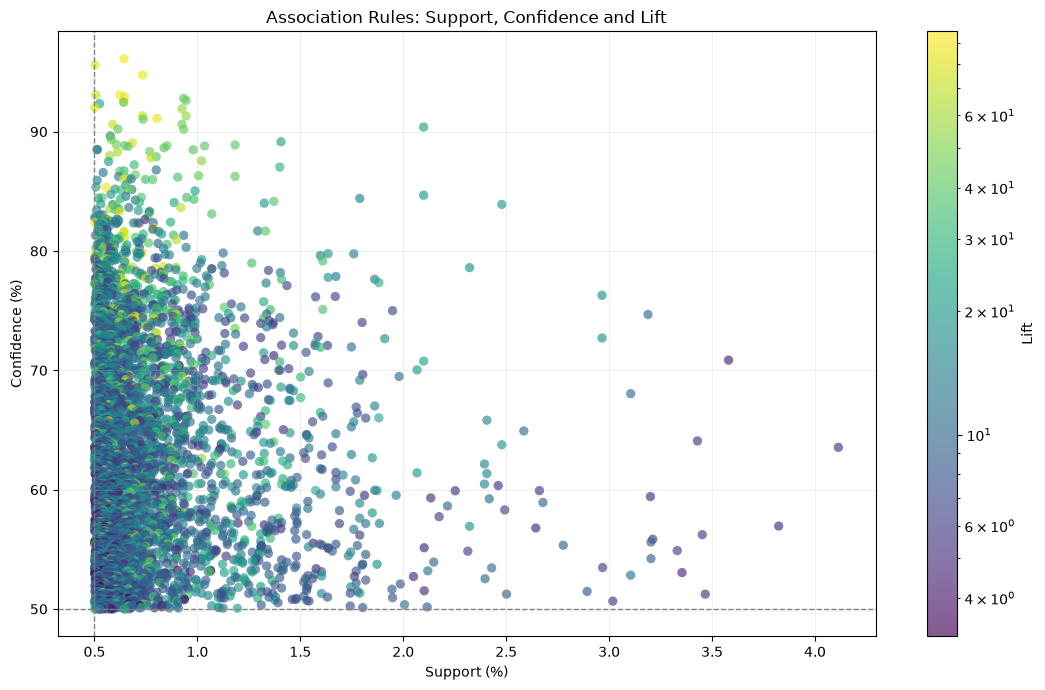

In [41]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(
    figsize=(11, 7)
)

scatter = ax.scatter(
    final_rules["SupportPercent"],
    final_rules["ConfidencePercent"],
    c=final_rules["lift"],
    s=45,
    cmap="viridis",
    norm=LogNorm(
        vmin=final_rules["lift"].min(),
        vmax=final_rules["lift"].max()
    ),
    alpha=0.65,
    edgecolors="none"
)

colour_bar = fig.colorbar(
    scatter,
    ax=ax
)

colour_bar.set_label("Lift")

ax.axvline(
    MIN_SUPPORT * 100,
    color="grey",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    ACTIONABLE_CONFIDENCE * 100,
    color="grey",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Association Rules: Support, Confidence and Lift"
)

ax.set_xlabel("Support (%)")
ax.set_ylabel("Confidence (%)")
ax.grid(alpha=0.20)

fig.tight_layout()

fig.savefig(
    market_basket_figure_dir
    / "rule_support_confidence_lift.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Strongest recommendation rules Plot

Select 15 non-reversed one-to-one product rules:

In [42]:
import textwrap

TOP_RULES_TO_PLOT = 15

top_rules_plot = (
    visualization_rules
    .head(TOP_RULES_TO_PLOT)
    .copy()
)

In [43]:
top_rules_plot[
    "RuleLabel"
] = top_rules_plot.apply(
    lambda row: textwrap.shorten(
        (
            row["AntecedentProducts"]
            + " → "
            + row["ConsequentProducts"]
        ),
        width=90,
        placeholder="…"
    ),
    axis=1
)

top_rules_plot = (
    top_rules_plot
    .sort_values(
        "confidence",
        ascending=True
    )
)

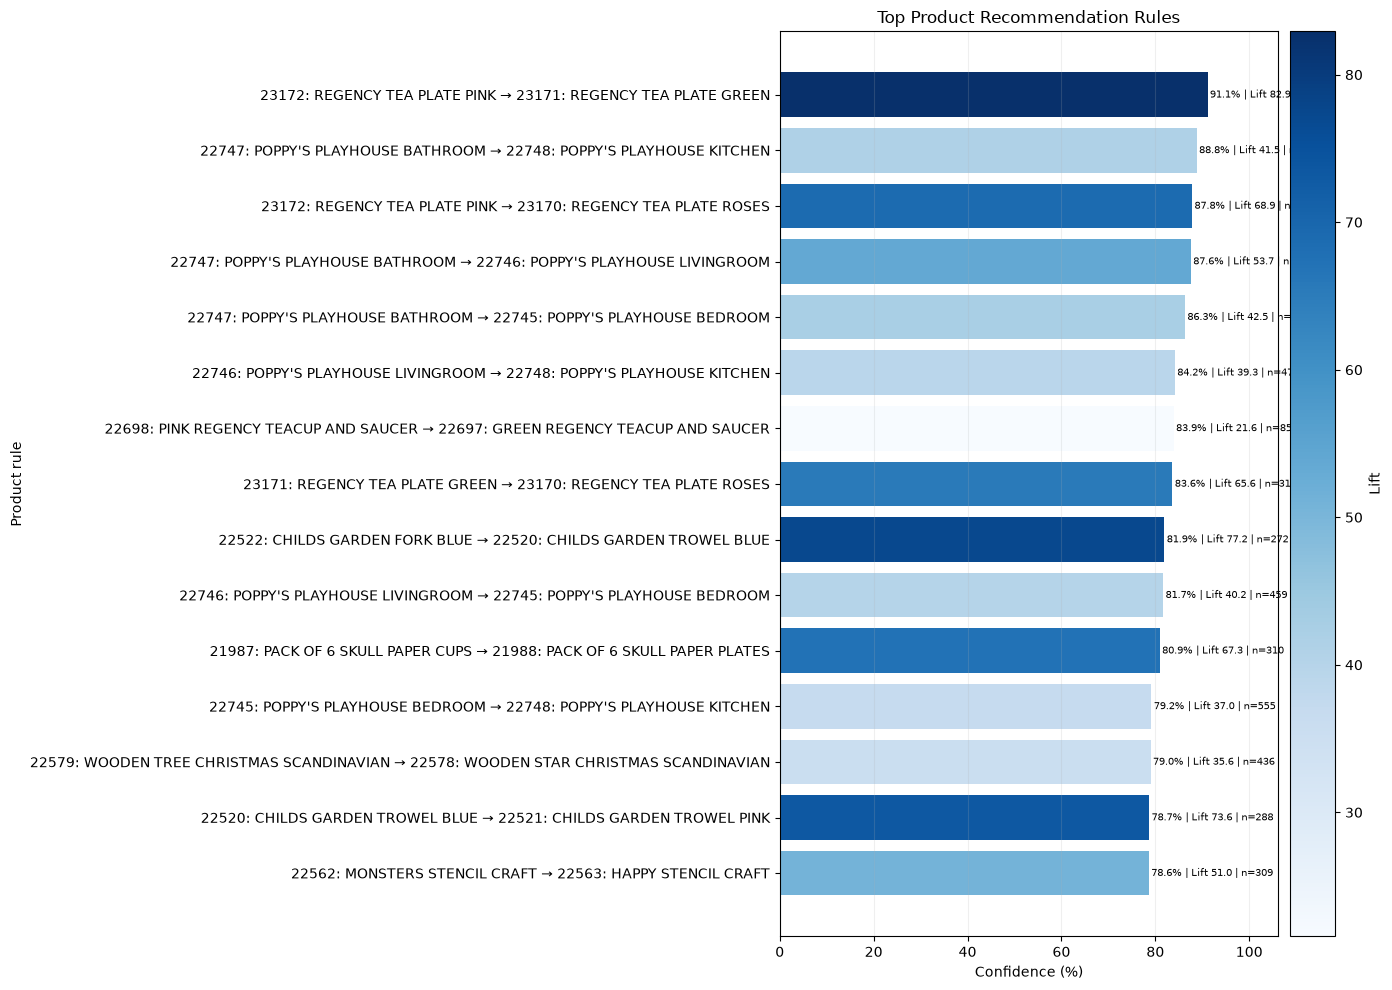

In [44]:
lift_normalizer = plt.Normalize(
    top_rules_plot["lift"].min(),
    top_rules_plot["lift"].max()
)

colour_map = plt.cm.Blues

bar_colours = colour_map(
    lift_normalizer(
        top_rules_plot["lift"]
    )
)

fig, ax = plt.subplots(
    figsize=(14, 10)
)

bars = ax.barh(
    top_rules_plot["RuleLabel"],
    top_rules_plot["ConfidencePercent"],
    color=bar_colours
)

for bar, (_, rule) in zip(
    bars,
    top_rules_plot.iterrows()
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        (
            f'{rule["ConfidencePercent"]:.1f}%'
            f' | Lift {rule["lift"]:.1f}'
            f' | n={rule["BasketCount"]}'
        ),
        va="center",
        fontsize=7
    )

colour_scale = plt.cm.ScalarMappable(
    norm=lift_normalizer,
    cmap=colour_map
)

colour_scale.set_array([])

colour_bar = fig.colorbar(
    colour_scale,
    ax=ax,
    pad=0.02
)

colour_bar.set_label("Lift")

ax.set_title(
    "Top Product Recommendation Rules"
)

ax.set_xlabel("Confidence (%)")
ax.set_ylabel("Product rule")

ax.set_xlim(
    0,
    min(
        110,
        top_rules_plot[
            "ConfidencePercent"
        ].max() + 15
    )
)

ax.grid(
    axis="x",
    alpha=0.20
)

fig.tight_layout()

fig.savefig(
    market_basket_figure_dir
    / "top_product_rules.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Interpretation

The support–confidence plot compares rule reliability with transaction coverage. Colour represents lift, where higher values indicate stronger associations relative to the products’ normal purchase rates.

The ranked rules chart highlights product combinations suitable for cross-selling, bundle design and recommendation prompts. Confidence indicates how frequently the consequent product is purchased when the antecedent product is present. Basket count provides the number of observed transactions supporting each relationship.

These associations indicate co-purchase behaviour, not causation. Promotional decisions should therefore be validated through controlled testing.

Create a product-association network

This network uses the strongest direction from each one-to-one product pair.

In [45]:
#%pip install networkx

In [46]:
import networkx as nx
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

Select the top 20 relationships:

In [47]:
TOP_NETWORK_RULES = 20

network_rules = (
    visualization_rules
    .head(TOP_NETWORK_RULES)
    .copy()
)

if network_rules.empty:
    raise ValueError(
        "No visualization rules are available."
    )

print(
    "Network relationships:",
    len(network_rules)
)

Network relationships: 20


Create the directed network:

In [48]:
product_network = nx.DiGraph()

for _, rule in network_rules.iterrows():
    antecedent_code = rule["AntecedentKey"]
    consequent_code = rule["ConsequentKey"]

    product_network.add_edge(
        antecedent_code,
        consequent_code,
        confidence=rule["ConfidencePercent"],
        lift=rule["lift"],
        basket_count=rule["BasketCount"]
    )

print(
    "Network products:",
    product_network.number_of_nodes()
)

print(
    "Network connections:",
    product_network.number_of_edges()
)

Network products: 24
Network connections: 20


Create concise node labels:

In [49]:
def create_network_label(stock_code):
    description = product_description_lookup.get(
        stock_code,
        "Description unavailable"
    )

    short_description = textwrap.shorten(
        str(description),
        width=28,
        placeholder="…"
    )

    return (
        f"{stock_code}\n"
        f"{short_description}"
    )


network_labels = {
    node: create_network_label(node)
    for node in product_network.nodes
}

Prepare node and edge styling:

In [50]:
network_position = nx.spring_layout(
    product_network,
    seed=42,
    k=1.4
)

node_sizes = [
    900
    + product_network.degree(node) * 250
    for node in product_network.nodes
]

edge_lifts = np.array([
    attributes["lift"]
    for _, _, attributes
    in product_network.edges(data=True)
])

edge_confidences = np.array([
    attributes["confidence"]
    for _, _, attributes
    in product_network.edges(data=True)
])

if edge_lifts.max() == edge_lifts.min():
    edge_widths = np.full(
        len(edge_lifts),
        2.5
    )
else:
    edge_widths = (
        1.5
        + 4
        * (
            edge_lifts - edge_lifts.min()
        )
        / (
            edge_lifts.max()
            - edge_lifts.min()
        )
    )

Visualization

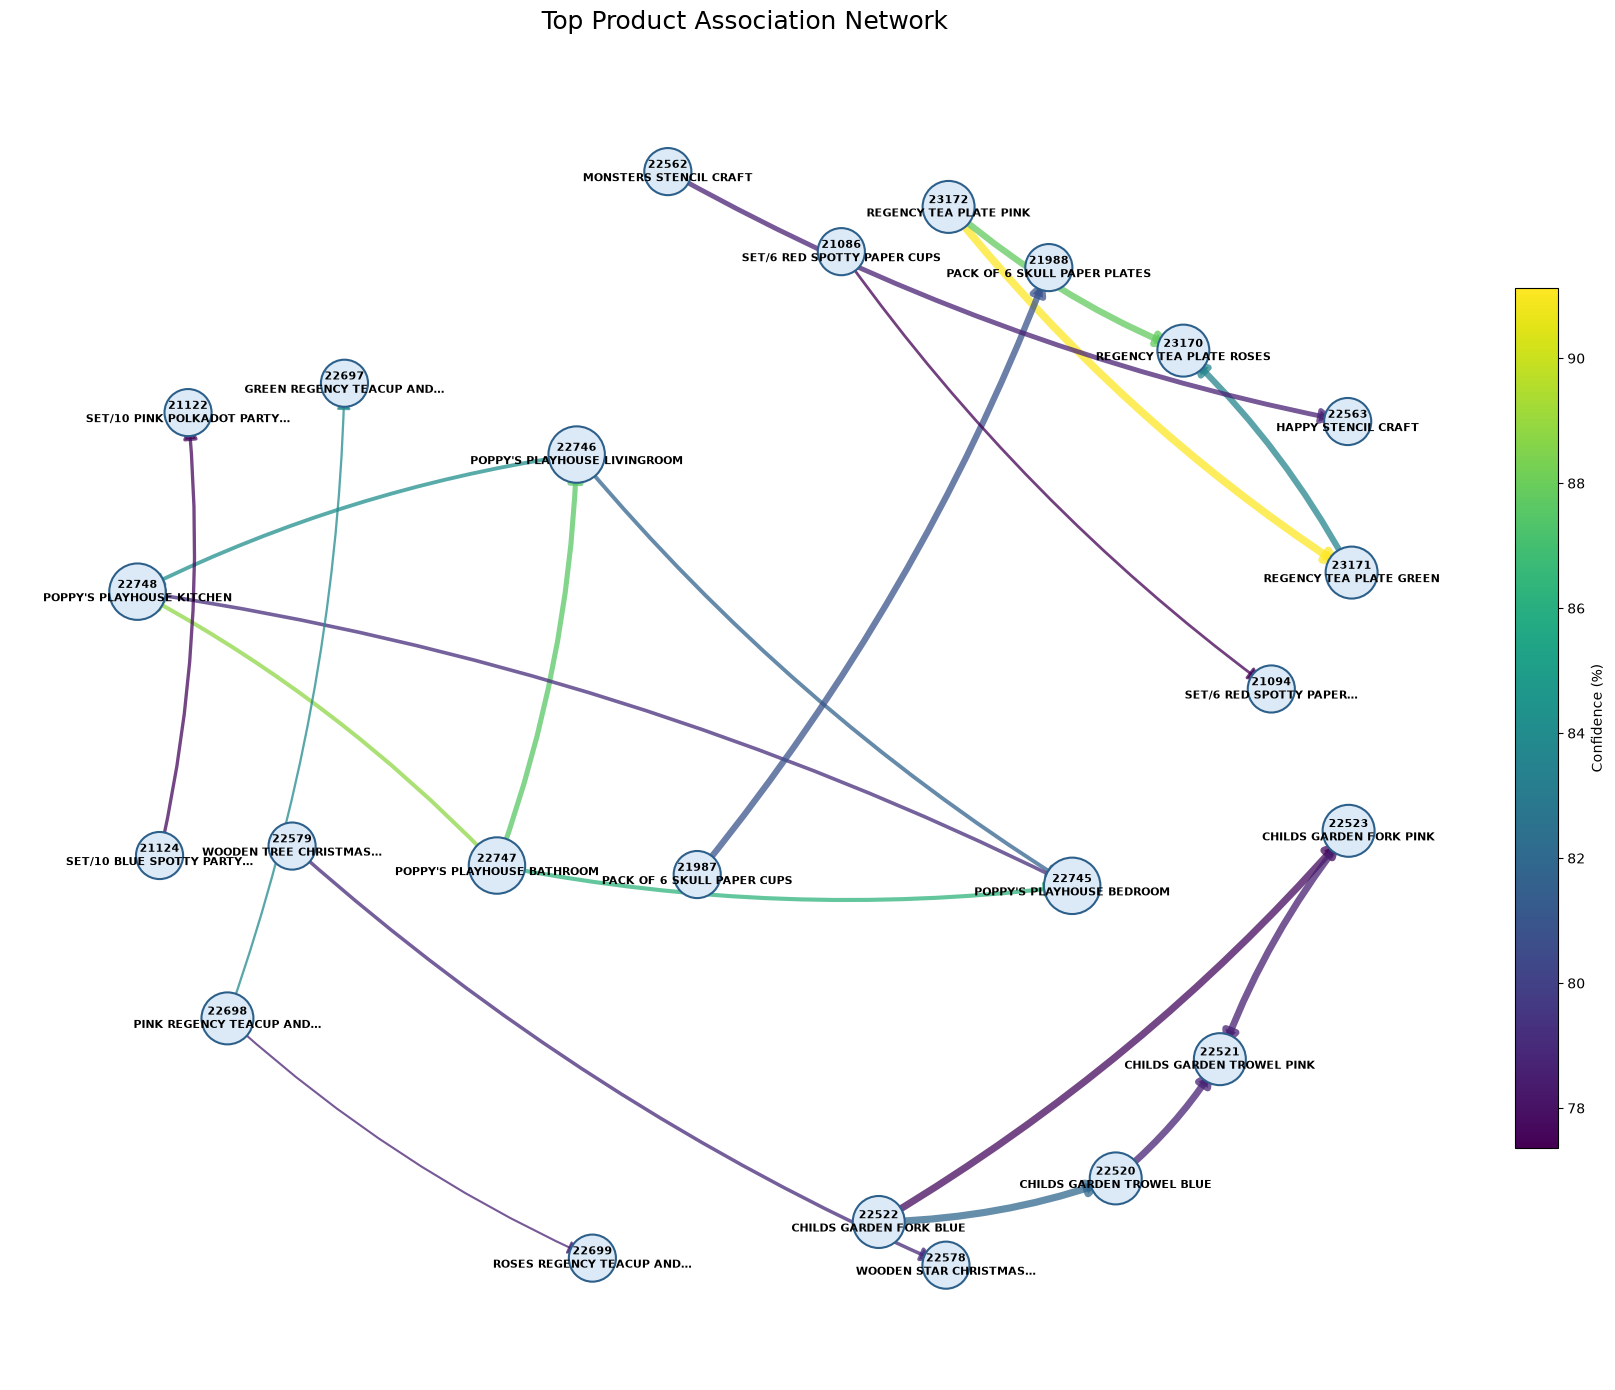

In [51]:
confidence_normalizer = Normalize(
    vmin=edge_confidences.min(),
    vmax=edge_confidences.max()
)

confidence_colour_map = plt.cm.viridis

edge_colours = [
    confidence_colour_map(
        confidence_normalizer(confidence)
    )
    for confidence in edge_confidences
]

fig, ax = plt.subplots(
    figsize=(18, 14)
)

nx.draw_networkx_nodes(
    product_network,
    network_position,
    node_size=node_sizes,
    node_color="#DCEAF7",
    edgecolors="#2C5F8A",
    linewidths=1.5,
    ax=ax
)

nx.draw_networkx_edges(
    product_network,
    network_position,
    width=edge_widths,
    edge_color=edge_colours,
    arrows=True,
    arrowsize=20,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.08",
    alpha=0.75,
    ax=ax
)

nx.draw_networkx_labels(
    product_network,
    network_position,
    labels=network_labels,
    font_size=8,
    font_weight="bold",
    ax=ax
)

colour_scale = ScalarMappable(
    norm=confidence_normalizer,
    cmap=confidence_colour_map
)

colour_scale.set_array([])

colour_bar = fig.colorbar(
    colour_scale,
    ax=ax,
    shrink=0.65,
    pad=0.02
)

colour_bar.set_label("Confidence (%)")

ax.set_title(
    "Top Product Association Network",
    fontsize=18,
    pad=20
)

ax.axis("off")

fig.tight_layout()

fig.savefig(
    market_basket_figure_dir
    / "product_association_network.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Product Association Network Interpretation

Each node represents a product, and each arrow represents the strongest retained recommendation direction between two products. An arrow from Product A to Product B indicates that Product B is a potential recommendation when Product A is present in a basket.

Edge colour represents confidence, while edge thickness represents lift. Larger nodes participate in more of the selected relationships. The network is restricted to the strongest rules to maintain readability and should not be interpreted as a complete representation of every product relationship.

Final market-basket validation

In [52]:
basket_sizes = (
    basket_model_lines
    .groupby("Invoice")[
        "StockCodeNormalized"
    ]
    .nunique()
)

market_basket_validation = {
    "multi_product_baskets": bool(
        basket_sizes.ge(2).all()
    ),
    "maximum_products_respected": bool(
        basket_matrix.shape[1]
        <= MAX_PRODUCTS
    ),
    "matrix_matches_source": bool(
        sparse_matrix.nnz
        == len(basket_model_lines)
    ),
    "minimum_support_respected": bool(
        final_rules["support"]
        .ge(MIN_SUPPORT)
        .all()
    ),
    "minimum_confidence_respected": bool(
        final_rules["confidence"]
        .ge(ACTIONABLE_CONFIDENCE)
        .all()
    ),
    "minimum_lift_respected": bool(
        final_rules["lift"]
        .ge(ACTIONABLE_LIFT)
        .all()
    ),
    "single_product_consequents": bool(
        final_rules["ConsequentSize"]
        .eq(1)
        .all()
    ),
    "duplicate_directional_rules": int(
        final_rules.duplicated(
            [
                "AntecedentKey",
                "ConsequentKey"
            ]
        ).sum()
    )
}

market_basket_validation

{'multi_product_baskets': True,
 'maximum_products_respected': True,
 'matrix_matches_source': True,
 'minimum_support_respected': True,
 'minimum_confidence_respected': True,
 'minimum_lift_respected': True,
 'single_product_consequents': True,
 'duplicate_directional_rules': 0}

In [53]:
assert all([
    market_basket_validation[
        "multi_product_baskets"
    ],
    market_basket_validation[
        "maximum_products_respected"
    ],
    market_basket_validation[
        "matrix_matches_source"
    ],
    market_basket_validation[
        "minimum_support_respected"
    ],
    market_basket_validation[
        "minimum_confidence_respected"
    ],
    market_basket_validation[
        "minimum_lift_respected"
    ],
    market_basket_validation[
        "single_product_consequents"
    ]
])

assert (
    market_basket_validation[
        "duplicate_directional_rules"
    ]
    == 0
)

print("All market-basket validations passed.")

All market-basket validations passed.


Prepare export tables

Analysis summary

In [54]:
matrix_density_percent = (
    sparse_matrix.nnz
    / (
        basket_matrix.shape[0]
        * basket_matrix.shape[1]
    )
    * 100
)

market_basket_summary = pd.DataFrame([
    {
        "EligibleBaskets": (
            basket_matrix.shape[0]
        ),
        "SelectedProducts": (
            basket_matrix.shape[1]
        ),
        "ProductPresences": (
            sparse_matrix.nnz
        ),
        "MatrixDensityPercent": (
            matrix_density_percent
        ),
        "MinimumSupport": MIN_SUPPORT,
        "MinimumBasketCount": int(
            np.ceil(
                MIN_SUPPORT
                * basket_matrix.shape[0]
            )
        ),
        "MinimumActionableConfidence": (
            ACTIONABLE_CONFIDENCE
        ),
        "MinimumActionableLift": (
            ACTIONABLE_LIFT
        ),
        "MaximumItemsetLength": (
            MAX_ITEMSET_LENGTH
        ),
        "FrequentItemsets": len(
            frequent_itemsets
        ),
        "AssociationRulesGenerated": len(
            association_rule_results
        ),
        "FinalActionableRules": len(
            final_rules
        )
    }
])

market_basket_summary

,EligibleBaskets,SelectedProducts,ProductPresences,MatrixDensityPercent,MinimumSupport,MinimumBasketCount,MinimumActionableConfidence,MinimumActionableLift,MaximumItemsetLength,FrequentItemsets,AssociationRulesGenerated,FinalActionableRules
0,34497,1000,675889,1.959269,0.005,173,0.5,1.2,3,10157,6305,4048


Frequent itemsets

Convert frozensets into text before saving:

In [55]:
frequent_itemsets_export = (
    frequent_itemsets
    .copy()
)

frequent_itemsets_export[
    "Itemsets"
] = frequent_itemsets_export[
    "itemsets"
].apply(create_itemset_key)

frequent_itemsets_export = (
    frequent_itemsets_export[
        [
            "Itemsets",
            "ItemsetSize",
            "support",
            "BasketCount"
        ]
    ]
    .rename(
        columns={
            "support": "Support"
        }
    )
)

Product support

In [56]:
product_support_export = (
    basket_model_lines
    .groupby(
        "StockCodeNormalized"
    )["Invoice"]
    .nunique()
    .rename("InvoiceCount")
    .sort_values(ascending=False)
    .reset_index()
)

product_support_export[
    "Description"
] = product_support_export[
    "StockCodeNormalized"
].map(product_description_lookup)

product_support_export[
    "SupportPercent"
] = (
    product_support_export[
        "InvoiceCount"
    ]
    / basket_matrix.shape[0]
    * 100
)

Visualization rules

In [57]:
visualization_rules_export = (
    visualization_rules[
        [
            "AntecedentProducts",
            "ConsequentProducts",
            "SupportPercent",
            "ConfidencePercent",
            "lift",
            "BasketCount"
        ]
    ]
    .rename(
        columns={
            "lift": "Lift"
        }
    )
)

Export the results

In [58]:
market_basket_output_dir = (
    project_root
    / "data"
    / "processed"
    / "market_basket"
)

market_basket_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [59]:
market_basket_exports = {
    "market_basket_summary.csv": (
        market_basket_summary
    ),
    "product_support.csv.gz": (
        product_support_export
    ),
    "frequent_itemsets.csv.gz": (
        frequent_itemsets_export
    ),
    "association_rules.csv.gz": (
        final_recommendation_rules
    ),
    "visualization_rules.csv": (
        visualization_rules_export
    )
}

export_records = []

for filename, export_df in (
    market_basket_exports.items()
):
    output_file = (
        market_basket_output_dir
        / filename
    )

    export_df.to_csv(
        output_file,
        index=False,
        compression=(
            "gzip"
            if filename.endswith(".gz")
            else None
        )
    )

    export_records.append({
        "File": filename,
        "Rows": len(export_df),
        "Columns": export_df.shape[1],
        "SizeMB": round(
            output_file.stat().st_size
            / 1_000_000,
            3
        )
    })

export_manifest = pd.DataFrame(
    export_records
)

export_manifest.to_csv(
    market_basket_output_dir
    / "export_manifest.csv",
    index=False
)

export_manifest

,File,Rows,Columns,SizeMB
0,market_basket_summary.csv,1,12,0.000
1,product_support.csv.gz,1000,4,0.022
2,frequent_itemsets.csv.gz,10157,4,0.070
3,association_rules.csv.gz,4048,9,0.165
4,visualization_rules.csv,344,6,0.045


Verify the saved rules

In [60]:
saved_rules = pd.read_csv(
    market_basket_output_dir
    / "association_rules.csv.gz"
)

assert len(saved_rules) == len(
    final_recommendation_rules
)

assert {
    "AntecedentProducts",
    "ConsequentProducts",
    "SupportPercent",
    "ConfidencePercent",
    "Lift",
    "BasketCount"
}.issubset(saved_rules.columns)

print(
    "Saved association rules:",
    len(saved_rules)
)

print(
    "Market-basket outputs saved to:",
    market_basket_output_dir
)

Saved association rules: 4048
Market-basket outputs saved to: c:\Github\retail-financial-intelligence\data\processed\market_basket
